In [20]:
from __future__ import annotations

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pathlib import Path


# -----------------------------
# Coordinate systems
# -----------------------------

CRS_GEOGRAPHIC = "EPSG:4326"


# -----------------------------
# Map settings
# -----------------------------

OREGON_EXTENT = [
    -125,   # west
    -116,   # east
    42,     # south
    46.5    # north
]

MAP_PROJECTION = ccrs.PlateCarree()

tasmax_file_dir = '/home/redmond/data/pub/scripps_downscaled_CMIP6/LOCA2/CONUS_regions_split/ACCESS-CM2/n_west/0p0625deg/r1i1p1f1/historical/tasmax/'
tasmax_file_path = tasmax_file_dir + 'tasmax.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20220413.n_west.nc'

pr_file_dir = '/home/redmond/data/pub/scripps_downscaled_CMIP6/LOCA2/CONUS_regions_split/ACCESS-CM2/n_west/0p0625deg/r1i1p1f1/historical/pr/'
pr_file_path = pr_file_dir + 'pr.ACCESS-CM2.historical.r1i1p1f1.1950-2014.LOCA_16thdeg_v20240915.n_west.monthly.clim.nc'

pr_future_dir = '/home/redmond/data/pub/scripps_downscaled_CMIP6/LOCA2/CONUS_regions_split/ACCESS-CM2/n_west/0p0625deg/r1i1p1f1/ssp585/pr/'
pr_future_path = pr_future_dir + 'pr.ACCESS-CM2.ssp585.r1i1p1f1.2075-2100.LOCA_16thdeg_v20220519.monthly.n_west.nc'

In [ ]:
pr_hist_month_clim = xr.open_dataarray(pr_file_path)
pr_future_month = xr.open_dataarray(pr_future_path)
pr_future_month_clim = pr_future_month.groupby('time.month').mean(dim='time')
pr_future_month_clim = pr_future_month_clim.rename({"month": "month_of_year"})

In [34]:
pr_month_change_mape = (pr_future_month_clim - pr_hist_month_clim)/pr_hist_month_clim
pr_month_change_mae = (pr_future_month_clim - pr_hist_month_clim)


In [37]:
pr_month_change_mae

<xarray.DataArray (month_of_year: 12, lat: 120, lon: 229)> Size: 1MB
array([[[           nan,            nan,            nan, ...,
          4.8301581e-06,  4.0900750e-06,  3.3380593e-06],
        [           nan,            nan,            nan, ...,
          5.1845373e-06,  4.3822383e-06,  3.2519247e-06],
        [           nan,            nan,            nan, ...,
          3.8613152e-06,  4.7372623e-06,  3.9613005e-06],
        ...,
        [           nan, -5.4834381e-06, -6.6594366e-06, ...,
          2.2068384e-06,  2.9665759e-06,  3.0928466e-06],
        [           nan, -6.4199849e-06, -5.5154233e-06, ...,
          1.3050153e-06,  2.0132070e-06,  2.6733669e-06],
        [           nan, -2.8402137e-06, -3.3437391e-06, ...,
          1.7929738e-06,  2.0250277e-06,  2.2455110e-06]],

       [[           nan,            nan,            nan, ...,
          2.4800993e-06,  1.9829704e-06,  1.8669143e-06],
        [           nan,            nan,            nan, ...,
          2.2089644e-06,  1.9914387e-06,  1.6953263e-06],
        [           nan,            nan,            nan, ...,
          1.3209174e-06,  2.0692778e-06,  1.9028475e-06],
...
          1.1481354e-06,  1.0938968e-06,  1.3270947e-06],
        [           nan,  4.6259287e-05,  4.4958069e-05, ...,
          4.2285410e-07,  6.9112093e-07,  1.1980130e-06],
        [           nan,  4.9883238e-05,  4.6892572e-05, ...,
          6.1939181e-07,  8.0737436e-07,  1.0288045e-06]],

       [[           nan,            nan,            nan, ...,
          3.5594658e-06,  3.1261443e-06,  2.1521892e-06],
        [           nan,            nan,            nan, ...,
          4.1324165e-06,  3.5143748e-06,  2.1929600e-06],
        [           nan,            nan,            nan, ...,
          3.4122058e-06,  4.1770618e-06,  3.1675982e-06],
        ...,
        [           nan,  2.0068124e-05,  1.9616244e-05, ...,
          1.8297012e-06,  1.3148328e-06,  1.2026567e-06],
        [           nan,  2.2806693e-05,  2.0216234e-05, ...,
          2.7877436e-06,  2.4578903e-06,  2.1528258e-06],
        [           nan,  1.9699073e-05,  1.8810504e-05, ...,
          3.1178722e-06,  3.0226383e-06,  2.5839706e-06]]],
      shape=(12, 120, 229), dtype=float32)
Coordinates:
  * month_of_year  (month_of_year) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat            (lat) float64 960B 41.59 41.66 41.72 ... 48.91 48.97 49.03
  * lon            (lon) float64 2kB 235.0 235.0 235.1 ... 249.1 249.2 249.2
Attributes:
    units:        kg m-2 s-1
    region::      n_west
    clim_year_0:  1950
    clim_year_1:  2014

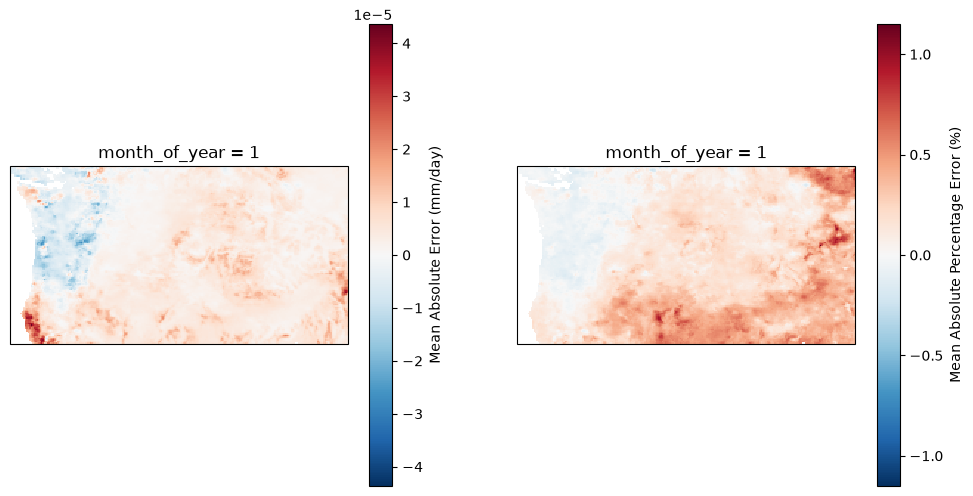

In [41]:
fig,axs = plt.subplots(1,2,figsize=(12, 6), subplot_kw={'projection': MAP_PROJECTION})

pr_month_change_mae.sel(month_of_year=1).plot(ax=axs[0], cmap='RdBu_r', cbar_kwargs={'label': 'Mean Absolute Error (mm/day)'})
pr_month_change_mape.sel(month_of_year=1).plot(ax=axs[1], cmap='RdBu_r', cbar_kwargs={'label': 'Mean Absolute Percentage Error (%)'})

In [40]:
pr_month_change.name

In [5]:
da.time

<xarray.DataArray 'time' (time: 23741)> Size: 190kB
array(['1950-01-01T12:00:00.000000000', '1950-01-02T12:00:00.000000000',
       '1950-01-03T12:00:00.000000000', ..., '2014-12-29T12:00:00.000000000',
       '2014-12-30T12:00:00.000000000', '2014-12-31T12:00:00.000000000'],
      shape=(23741,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 190kB 1950-01-01T12:00:00 ... 2014-12-31T1...
Attributes:
    long_name:  time